# P1 실습: 다층 퍼셉트론

**감사의 글**

아래 내용은 프랑소와 숄레의 
[Deep Learning with Python(3판)](https://github.com/fchollet/deep-learning-with-python-notebooks)의 
소스코드 내용을 참고해서 작성되었습니다.
자료를 공개한 저자에게 진심어린 감사를 전합니다.

**코드 실행**

[(구글 코랩) P1 실습: 머신러닝 프로젝트](https://colab.research.google.com/github/codingalzi/code-workout-dlp/blob/master/P1_lab_mlp.ipynb)에서 코드를 실행할 수 있다.

**주요 내용**

이 실습에서는 강의에서 배운 다층 퍼셉트론 모델을 **MNIST 손글씨 숫자 분류 문제**에 직접 적용한다.

목표는 코드를 처음부터 작성하는 것이 아니라, 코드를 실행하면서 다음 흐름을 확인하는 것이다.

> **데이터 확인 → 입력 준비 → 모델 구성 → 훈련 → 예측 → 평가 → 오류 확인**

**설정: TensorFlow와 Keras의 GPU 사용 가능 여부 확인**

In [1]:
# TensorFlow 를 사용할 때 기타 정보 표시 제한. Tensorflow를 불러오기 전에 실행해야 함
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
import keras
import torch

# TensorFlow
tf_gpus = tf.config.list_physical_devices("GPU")

print("=== TensorFlow ===")
print("Version:", tf.__version__)
print("GPU 사용 가능:", len(tf_gpus) > 0)
if tf_gpus:
    print("GPU:", tf_gpus[0].name)

print()

# PyTorch
print("=== PyTorch ===")
print("Version:", torch.__version__)
print("GPU 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

=== TensorFlow ===
Version: 2.20.0
GPU 사용 가능: True
GPU: /physical_device:GPU:0

=== PyTorch ===
Version: 2.9.1+cu128
GPU 사용 가능: True
GPU: NVIDIA RTX A6000
CUDA version: 12.8


## MNIST 데이터

MNIST는 `0`부터 `9`까지의 손글씨 숫자 이미지 데이터다.

- 훈련 이미지: 60,000장
- 테스트 이미지: 10,000장
- 이미지 한 장의 크기: `28 × 28`
- 타깃: 숫자 `0`부터 `9`

### MNIST 데이터 불러오기

먼저 데이터를 불러오고 shape을 확인한다.

In [2]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print("train_images:", train_images.shape)
print("train_labels:", train_labels.shape)
print("test_images :", test_images.shape)
print("test_labels :", test_labels.shape)

train_images: (60000, 28, 28)
train_labels: (60000,)
test_images : (10000, 28, 28)
test_labels : (10000,)


### MNIST 데이터 구조

`train_images.shape = (60000, 28, 28)`과  
`train_labels.shape = (60000,)`은 각각 무엇을 의미하는가?

두 shape의 첫 번째 숫자 `60000`은 어떤 관계를 나타내는가?

<details>
<summary><strong>해설 보기</strong></summary>

`train_images.shape = (60000, 28, 28)`은 60,000장의 이미지가 있고 각 이미지가 `28 × 28` 크기라는 뜻이다.

`train_labels.shape = (60000,)`은 각 이미지에 대응하는 타깃이 60,000개 있다는 뜻이다.

즉 **입력 샘플 수와 타깃 수가 서로 일치해야 한다.**

</details>

## 실제 이미지와 타깃 확인

### 실제 이미지 샘플 확인

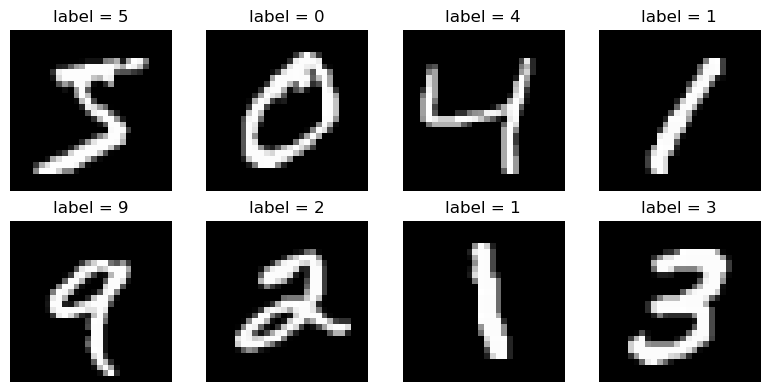

In [3]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 4))

for i in range(8):
    ax = fig.add_subplot(2, 4, i + 1)
    ax.imshow(train_images[i], cmap="gray")
    ax.set_title(f"label = {train_labels[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 입력과 타깃 확인

이미지와 타깃을 함께 보면서 다음을 확인해보자.

- 입력은 무엇인가?
- 타깃은 무엇인가?
- 왜 이 문제는 다중 클래스 분류 문제인가?

<details>
<summary><strong>해설 보기</strong></summary>

입력은 손글씨 숫자 이미지이고, 타깃은 `0`부터 `9`까지의 숫자다.  
10개의 범주 가운데 하나를 예측하므로 다중 클래스 분류 문제다.

</details>

## 완전연결층에 맞는 입력 데이터

MNIST 이미지 한 장의 원래 shape은 `(28, 28)`이다.

### 데이터 변환

하지만 이번에 사용할 `Dense` 층은 **완전연결층**이므로 이미지의 픽셀을 
하나의 벡터, 즉 1차원 어레이 형식으로 펼쳐서 입력해야 한다.

> `(28, 28) → (784,)`

또한 픽셀값의 범위를 `0~255`에서 `0~1`로 정규화한다.

입력값의 크기를 적절한 범위로 조정하면 신경망 훈련을 보다 안정적으로 진행할 수 있다.

In [4]:
print("변환 전:", train_images.shape)
print("픽셀값 범위:", train_images.min(), "~", train_images.max())

train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255

print("변환 후:", train_images.shape)
print("픽셀값 범위:", train_images.min(), "~", train_images.max())

변환 전: (60000, 28, 28)
픽셀값 범위: 0 ~ 255
변환 후: (60000, 784)
픽셀값 범위: 0.0 ~ 1.0


### reshape이란?

1. reshape 전후에 이미지 한 장에 들어 있는 값의 개수는 달라졌는가?
2. 왜 `(28, 28)`을 `(784,)`로 바꾸는가?
3. reshape는 이미지의 정보를 없애는가, 아니면 배열의 모양만 바꾸는가?
4. `/ 255`는 무엇을 바꾸는가?

<details>
<summary><strong>해설 보기</strong></summary>

1. 값의 개수는 변하지 않는다. `28 × 28 = 784`이다.
2. 완전연결층에 784개의 픽셀값을 하나의 입력 벡터로 전달하기 위해서다.
3. 픽셀값 자체는 없어지지 않지만, `(28, 28)`이라는 **2차원 공간 구조는 벡터 형태에서는 직접 드러나지 않는다.**
4. 픽셀값의 범위를 `0~255`에서 `0~1`로 바꾼다.

</details>

## Keras로 첫 신경망 구성

### 모델 구성

강의에서 본 기본 신경망을 그대로 사용한다.

> **784개의 입력값 → 512개의 은닉 유닛 → 10개의 출력값**

In [5]:
from keras import layers

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

### 모델 구조 확인

In [6]:
model.build(input_shape=(None, 28 * 28))
model.summary()

I0000 00:00:1789364982.506862    6740 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46007 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

`model.summary()`를 보고 확인해보자.

1. 첫 번째 `Dense` 층의 출력 크기는 얼마인가?
2. 마지막 `Dense` 층의 출력이 10개인 이유는 무엇인가?
3. 강의에서 계산한 파라미터 수와 `model.summary()`의 값이 일치하는가?
4. 첫 번째 `Dense` 층의 파라미터 수가 두 번째 `Dense` 층보다 훨씬 많은 이유는 무엇인가?

<details>
<summary><strong>해설 보기</strong></summary>

- 첫 번째 `Dense` 층은 512개의 값을 출력한다.
- MNIST의 숫자 범주가 10개이므로 마지막 출력도 10개다.
- 첫 층의 파라미터 수는 `784 × 512 + 512`, 두 번째 층은 `512 × 10 + 10`이다.
- 첫 번째 층은 **784개의 입력값과 512개의 출력 유닛이 모두 연결**되기 때문에 훨씬 많은 가중치가 필요하다.

</details>

## 신경망 모델 훈련 준비

모델을 훈련하려면 다음 세 가지를 지정한다.

- **optimizer**: 파라미터를 어떻게 갱신할지 결정
- **loss**: 예측이 얼마나 틀렸는지 측정
- **metric**: 성능을 어떤 지표로 확인할지 결정

지금은 각 이름을 외우기보다 **코드에서 어떤 역할을 맡는지** 확인한다.

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## 신경망 모델 훈련

### 검증 데이터 활용

훈련 과정에서 일부 훈련 데이터를 **검증 데이터**로 분리한다.

훈련 정확도만 보는 것이 아니라, 학습하지 않은 검증 데이터에서도 성능이 어떻게 변하는지 함께 확인하기 위해서다.

In [8]:
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/5
112/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7582 - loss: 0.8471

I0000 00:00:1789364985.657964    6884 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9161 - loss: 0.2976 - val_accuracy: 0.9513 - val_loss: 0.1722
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9648 - loss: 0.1250 - val_accuracy: 0.9661 - val_loss: 0.1116
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9765 - loss: 0.0824 - val_accuracy: 0.9708 - val_loss: 0.0954
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9835 - loss: 0.0578 - val_accuracy: 0.9725 - val_loss: 0.0925
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9879 - loss: 0.0428 - val_accuracy: 0.9755 - val_loss: 0.0831


### 훈련 로그 읽기

훈련 결과에서 다음을 찾아보자.

- `loss`
- `accuracy`
- `val_loss`
- `val_accuracy`

그리고 에포크가 진행되면서 각각 어떻게 변하는지 관찰한다.

## 모델 훈련 과정 시각화

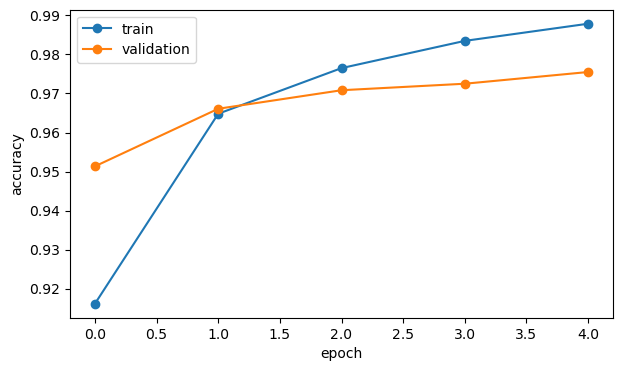

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], marker="o", label="train")
plt.plot(history.history["val_accuracy"], marker="o", label="validation")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

훈련 정확도와 검증 정확도는 다르게 변한다.

훈련 정확도는 에포크가 증가하면서 계속 높아진다.

반면 검증 정확도는 어느 순간부터 증가 속도가 둔화되거나 조금 낮아질 수 있다. 이런 차이는 이후 과대적합을 이해할 때 중요한 단서가 된다.

지금은 과대적합을 자세히 분석하지 않는다. 다만 다음 질문을 기억해두자.

> **훈련 데이터에서 잘 맞는 것과 새로운 데이터에서도 잘 맞는 것은 같은가?**

## 새로운 데이터 예측

### `predict()` 메서드 활용

테스트 이미지 몇 장에 대해 모델의 출력을 확인한다.

출력은 10개의 값이며, 각 값은 숫자 `0`부터 `9`에 대응한다.

In [10]:
predictions = model.predict(test_images[:10], verbose=0)

i = 0
print("10개 출력:", predictions[i])
print("예측 숫자:", predictions[i].argmax())
print("가장 큰 출력값:", predictions[i].max())
print("실제 정답:", test_labels[i])

10개 출력: [7.5246106e-07 6.6855961e-08 6.7598099e-05 1.8132074e-03 1.4629432e-09
 8.1287067e-07 2.5664752e-11 9.9806005e-01 1.7307322e-06 5.5716464e-05]
예측 숫자: 7
가장 큰 출력값: 0.99806005
실제 정답: 7


다음 질문에 답해보자.

1. `predictions` 변수에는 어떤 값들이 저장되어 있는가?
2. `predictions[0]`의 10개 값은 각각 무엇을 의미하는가?
3. `argmax()`는 어떤 역할을 하는가?
4. 가장 큰 값만 보는 것과 10개 출력값 전체를 보는 것은 어떤 차이가 있는가?

<details>
<summary><strong>해설 보기</strong></summary>

1. 처음 10개의 테스트 이미지에 대한 예측값으로 구성된 (10, 10) 모양의 2차원 어레이다.
2. 10개 출력값은 숫자 `0`부터 `9`까지 각 범주에 대응한다.
3. `argmax()`는 10개 출력값 가운데 가장 큰 값의 위치를 찾아 최종 예측 범주를 정한다.
4. 가장 큰 값만 보면 최종 예측만 알 수 있지만, 10개 값을 함께 보면 모델이 다른 숫자들에 어느 정도의 값을 주었는지도 확인할 수 있다.

</details>

즉, 한 이미지의 예측 과정은 다음과 같이 읽을 수 있다.

> **이미지 → 784개 입력값 → 신경망 → 10개 출력 → 가장 큰 값의 위치 → 예측 숫자**


### 예측값을 이미지와 함께 확인

첫 번째 테스트 이미지는 숫자 7처럼 보인다.

예측값도 숫자 7이다.

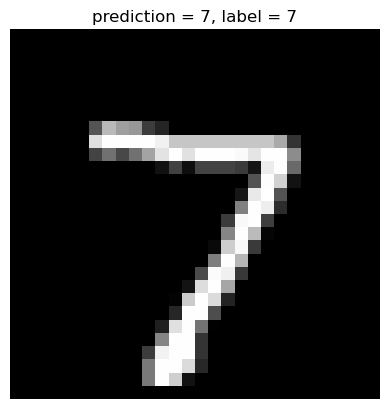

In [11]:
# 원래 모양으로 되돌려 시각화
image = test_images[0].reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.title(
    f"prediction = {predictions[0].argmax()}, " # 예측값
    f"label = {test_labels[0]}"                 # 실제 정답 라벨
)
plt.axis("off")
plt.show()

## 모델 성능 최종 평가

훈련에 사용하지 않은 테스트 데이터 전체에서 모델의 성능을 확인한다.

In [12]:
test_loss, test_acc = model.evaluate(
    test_images,
    test_labels,
    batch_size=128,
)

print(f"test loss     : {test_loss:.4f}")
print(f"test accuracy : {test_acc:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9761 - loss: 0.0767
test loss     : 0.0767
test accuracy : 0.9761


## 틀린 예측 찾아보기

정확도 하나만으로는 모델이 **어떤 경우에 틀리는지** 알 수 없다.

잘못 분류된 이미지를 직접 찾아본다.

In [13]:
all_predictions = model.predict(test_images, verbose=0).argmax(axis=1)

wrong_indices = (all_predictions != test_labels).nonzero()[0]

print("오분류 개수:", len(wrong_indices))
print("전체 테스트 이미지:", len(test_labels))

오분류 개수: 239
전체 테스트 이미지: 10000


잘못 예측된 205개 테스트 이미지 중에 처음 12개 이미지는 다음과 같다.

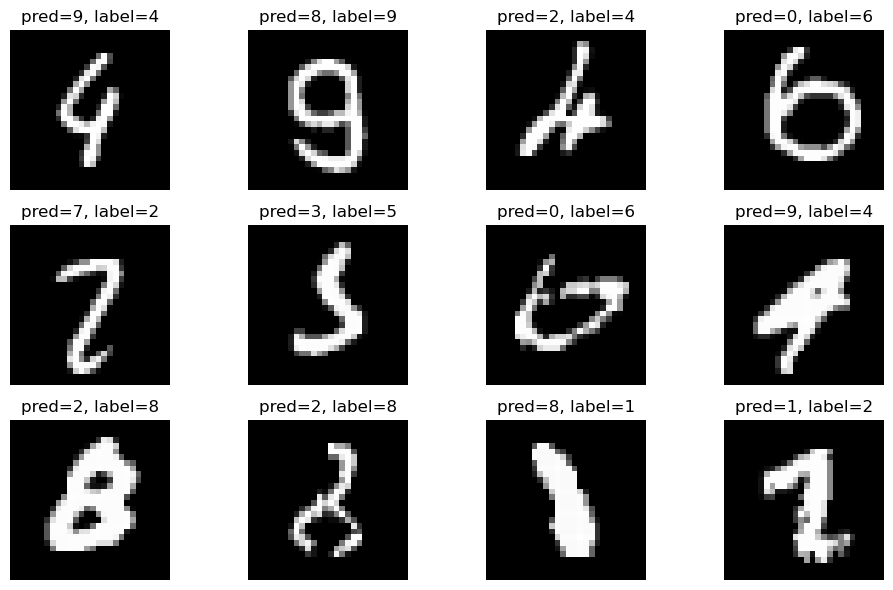

In [14]:
fig = plt.figure(figsize=(10, 6))

for j, idx in enumerate(wrong_indices[:12]):
    ax = fig.add_subplot(3, 4, j + 1)
    ax.imshow(test_images[idx].reshape(28, 28), cmap="gray")
    ax.set_title(
        f"pred={all_predictions[idx]}, label={test_labels[idx]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

오분류 이미지를 몇 장 살펴보고 다음을 생각해보자.

1. 사람이 보기에도 애매한 이미지가 있는가?
2. 특정 숫자 쌍에서 혼동이 자주 보이는가?
3. 테스트 정확도 하나만 보고는 알 수 없었던 사실은 무엇인가?

이 질문들은 Fashion-MNIST 프로젝트에서 더 체계적으로 다룬다.

## PyTorch 다층 퍼셉트론

Keras의 MNIST 신경망 모델과 동일한 모델을 PyTorch로 표현하여 훈련시킨다.

목표는 새로운 딥러닝 원리를 배우는 것이 아니라,

> **Keras에서 사용한 구조와 훈련 과정이 PyTorch에서는 어떻게 드러나는가?**

를 확인하는 것이다.

Keras에서 사용한 구조는 다음과 같았다.

> **784개의 입력값 → 512개의 은닉 유닛 → 10개의 출력값**

### PyTorch의 MNIST 신경망 모델

In [15]:
import torch
from torch import nn

torch_model = nn.Sequential(
    nn.Linear(28 * 28, 512),
    nn.ReLU(),
    nn.Linear(512, 10),
)

torch_model

Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=10, bias=True)
)

### 신경망 모델 구조 비교

Keras와 PyTorch에서 대응하는 요소를 찾아보자.

| 개념 | Keras | PyTorch |
|---|---|---|
| 완전연결층 | `Dense` | `nn.Linear` |
| ReLU | `activation="relu"` | `nn.ReLU()` |
| 모델 연결 | `Sequential` | `nn.Sequential` |
| 출력 수 | 10 | 10 |

두 프레임워크의 문법은 다르지만 **모델의 구조 자체는 같다.**

다음 질문에 답해보자.

1. `nn.Linear(28 * 28, 512)`에서 두 숫자는 각각 무엇을 뜻하는가?
2. 마지막 층의 출력이 10개인 이유는 Keras와 동일한가?

<details>
<summary><strong>해설 보기</strong></summary>

1. 784개의 입력값을 받아 512개의 값을 출력한다는 뜻이다.
2. 동일하다. MNIST에서 예측해야 하는 숫자 범주가 10개이기 때문이다.

</details>

## PyTorch에서 데이터 배치 준비

### 배치 묶음 데이터 생성

PyTorch에서는 데이터와 타깃을 `Tensor`로 만들고, `DataLoader`를 이용해 **배치 단위**로 전달하는 방식이 일반적이다.

앞에서 Keras용으로 `(60000, 784)` 형태로 준비한 데이터를 그대로 이용한다.

In [16]:
from torch.utils.data import TensorDataset, DataLoader

x_train_t = torch.tensor(train_images, dtype=torch.float32)
y_train_t = torch.tensor(train_labels, dtype=torch.long)

x_test_t = torch.tensor(test_images, dtype=torch.float32)
y_test_t = torch.tensor(test_labels, dtype=torch.long)

train_dataset = TensorDataset(x_train_t, y_train_t)
test_dataset = TensorDataset(x_test_t, y_test_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
)

### 배치 shape

PyTorch의 `DataLoader`는 데이터를 지정한 배치 크기만큼 묶어 **배치 단위로 전달할 준비를 하는 객체**다.

현재 `batch_size=128`이므로 훈련 과정에서는 한 번에 128개의 샘플이 전달된다.

- 입력 배치: `(128, 784)`
- 타깃 배치: `(128,)`

타깃 배치의 shape이 `(128,)`인 이유를 설명해보자.

<details>
<summary><strong>해설 보기</strong></summary>

각 입력 샘플 하나에 숫자 타깃 하나가 대응하므로, 128개 입력 샘플에 대해 128개의 타깃이 존재한다.

</details>

즉, Keras에서는 `fit()`을 호출하면 이러한 **배치 구성과 배치 단위 데이터 전달을 내부에서 처리**하는 반면에,
PyTorch에서는 `DataLoader`를 사용하여 이 과정을 코드에서 명시적으로 준비해야 한다.

## PyTorch의 훈련 루프

Keras에서는 `model.fit()`이 훈련 과정을 내부에서 처리했다.

PyTorch에서는 아래 훈련 과정을 코드에서 직접 구현한다.

> **gradient 초기화 → 순전파 → loss 계산 → 역전파 → 파라미터 갱신**

또한 Keras와 달리 PyTorch에서는 GPU 또는 CPU 중 어떤 **device**를 사용할지 명시적으로 지정한다.

훈련을 시작하기 전에 모델을 해당 device로 이동하고, 각 배치의 입력 데이터와 타깃도 같은 device로 이동하여 계산한다.

PyTorch에서는 훈련을 시작할 때

```python
torch_model.train()
````

을 사용하여 모델을 **훈련 모드**로 설정한다.

이와 대응하여 모델을 평가할 때는

```python
torch_model.eval()
```

을 사용하여 **평가 모드**로 전환한다.

즉 PyTorch에서는 Keras가 내부에서 처리하는 여러 과정을 코드에서 보다 명시적으로 확인할 수 있다.

In [17]:
# 훈련 device 지정: GPU 또는 CPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("device:", device)

# PyTorch 모델을 device로 이동
torch_model = torch_model.to(device)

# 손실 함수와 옵티마이저 정의
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(torch_model.parameters())

# 훈련 루프
epochs = 5  # 에포크 수

for epoch in range(epochs):
    torch_model.train()                   # 모델을 훈련 모드로 설정

    running_loss = 0.0                    # 누적 손실 초기화
    correct = 0                           # 누적 정답 개수 초기화
    total = 0                             # 누적 샘플 수 초기화

    # 배치 훈련
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)      # 입력 데이터를 GPU 또는 CPU로 이동
        y_batch = y_batch.to(device)      # 타깃 데이터를 GPU 또는 CPU로 이동

        optimizer.zero_grad()

        outputs = torch_model(x_batch)
        loss = loss_fn(outputs, y_batch)

        loss.backward()
        optimizer.step()

        # 배치 손실 누적
        running_loss += loss.item() * x_batch.size(0)
        # 정답 수 누적
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        # 배치 샘플 수 누적
        total += y_batch.size(0)

    epoch_loss = running_loss / total     # 에포크 평균 손실 계산
    epoch_acc = correct / total           # 에포크 정확도 계산

    print(
        f"epoch {epoch + 1}: "
        f"loss={epoch_loss:.4f}, accuracy={epoch_acc:.4f}"
    )

device: cuda
epoch 1: loss=0.3154, accuracy=0.9135
epoch 2: loss=0.1266, accuracy=0.9627
epoch 3: loss=0.0838, accuracy=0.9754
epoch 4: loss=0.0602, accuracy=0.9821
epoch 5: loss=0.0453, accuracy=0.9864


다음 코드가 각각 어떤 역할을 하는지 연결해보자.

- `optimizer.zero_grad()`
- `outputs = torch_model(x_batch)`
- `loss = loss_fn(outputs, y_batch)`
- `loss.backward()`
- `optimizer.step()`

<details>
<summary><strong>해설 보기</strong></summary>

- `optimizer.zero_grad()`: 이전 배치에서 계산된 gradient를 초기화한다.
- `torch_model(x_batch)`: 현재 파라미터로 예측값을 계산한다.
- `loss_fn(...)`: 예측과 타깃의 차이를 측정한다.
- `loss.backward()`: loss를 기준으로 gradient를 계산한다.
- `optimizer.step()`: 계산된 gradient를 이용해 파라미터를 갱신한다.

</details>

Keras의 `fit()`에서는 이 과정이 내부에 숨겨져 있지만, PyTorch에서는 훈련 과정이 코드에 직접 드러난다.

## PyTorch 모델 평가

훈련이 끝난 뒤에는 테스트 데이터에서 정확도를 확인한다.

평가할 때는

- `model.eval()`
- `torch.no_grad()`

를 사용한다.

평가도 테스트 데이터를 배치 단위로 처리하고, 전체 샘플에 대한 정확도를 계산한다.

In [18]:
torch_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = torch_model(x_batch)
        predictions_t = outputs.argmax(dim=1)

        correct += (predictions_t == y_batch).sum().item()
        total += y_batch.size(0)

torch_test_acc = correct / total

print(f"PyTorch test accuracy: {torch_test_acc:.4f}")

PyTorch test accuracy: 0.9793


다음 두 질문에 답해보자.

1. `torch_model.eval()`은 왜 필요한가?
2. 평가할 때 `torch.no_grad()`를 사용하는 이유는 무엇인가?

<details>
<summary><strong>해설 보기</strong></summary>

1. 모델을 훈련 모드가 아닌 평가 모드로 전환한다.
2. 평가에서는 파라미터를 갱신하지 않으므로 gradient 계산이 필요하지 않다.

</details>

## Keras와 PyTorch 비교

같은 MNIST 문제를 두 프레임워크로 실행했다.

핵심 차이는 **딥러닝 원리**가 아니라 **코드를 표현하는 방식**이다.

| 과정 | Keras | PyTorch |
|---|---|---|
| 모델 구성 | `Dense`, `Sequential` | `nn.Linear`, `nn.Sequential` |
| 손실함수 | `compile(loss=...)` | `nn.CrossEntropyLoss()` |
| optimizer | `compile(optimizer=...)` | `torch.optim.Adam(...)` |
| 훈련 | `fit()` | 명시적인 반복문 |
| 예측 | `predict()` | `model(x)` |
| 평가 모드 | 내부 처리 | `model.eval()` |
| gradient 비활성화 | 내부 처리 | `torch.no_grad()` |

> **Keras와 PyTorch는 서로 다른 딥러닝이 아니라, 같은 딥러닝 원리를 서로 다른 방식으로 표현하는 프레임워크다.**

특히 PyTorch에서는 훈련 루프가 코드에 직접 드러나므로, 강의에서 배운 **순전파 → loss → 역전파 → 파라미터 갱신**을 확인하기 좋다.

## 실습 정리

이번 실습에서는 MNIST를 이용해 하나의 기본 신경망을 **Keras와 PyTorch 두 방식으로 확인**했다.

Keras에서는

> **데이터 → 모델 → `compile()` → `fit()` → 예측 → 평가**

의 전체 흐름을 빠르게 확인했다.

PyTorch에서는 같은 모델을 다시 표현하면서

> **배치 → 순전파 → loss → 역전파 → optimizer에 의한 파라미터 갱신**

과정을 코드에서 직접 확인했다.

다음 P1 프로젝트에서는 같은 원리를 **Fashion-MNIST**에 적용한다.

그때는 단순히 실습 코드를 다시 실행하는 것이 아니라,

> **어떤 모델을 사용할 것인가? 결과를 어떻게 비교할 것인가? 무엇을 개선할 것인가?**

를 스스로 판단한다.